# 7.7 填充的位置會被當線索嗎？


原序列是[1,2,3]，左邊補兩PAD後變[0,0,1,2,3]。若希望真實三格得到相同預測，就要讓它們不讀PAD，而且仍使用位置0、1、2。

因果遮罩只禁止未來，valid另禁止填充key；兩條要同時成立。圖裡物理欄位0到4用來找格子，模型位置ID最後三格仍0到2，兩種編號別混用。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

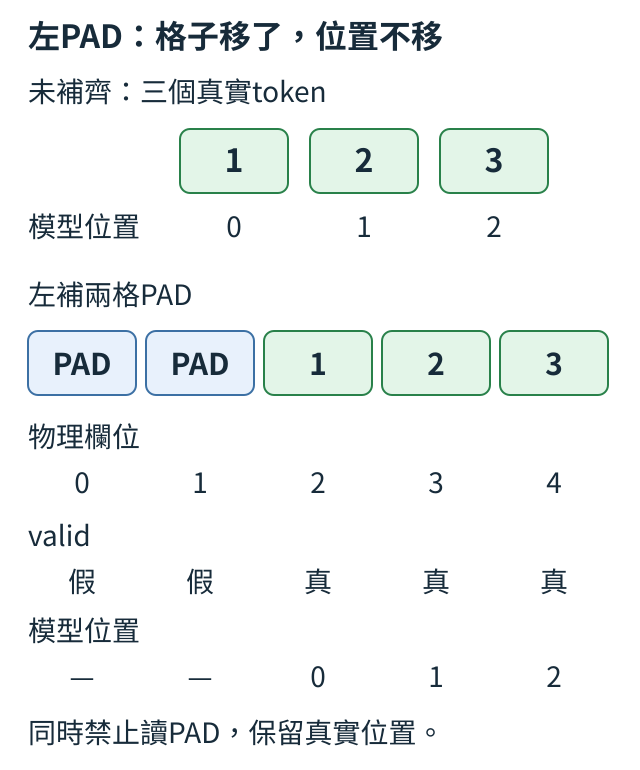

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/rewrite-07-07-padding-positions.svg")))

In [3]:
import torch
from tiny_perceptron.model import TinyLM, ModelConfig

torch.manual_seed(42)
model = TinyLM(ModelConfig(vocab_size=10, width=8))
base = model(torch.tensor([[1, 2, 3]]))["logits"]
ids = torch.tensor([[0, 0, 1, 2, 3]])
valid = ids != 0
positions = torch.tensor([[0, 0, 0, 1, 2]])
actual = model(ids, valid=valid, positions=positions)["logits"][:, 2:]
print("有效位置最大差", (base - actual).abs().max().item())
assert torch.allclose(base, actual, atol=1e-6, rtol=0.0)

有效位置最大差 0.0


未補齊輸入是一筆三個真實token，base保存它們的logits輸出。補齊版ids用0當PAD，valid是 `[False,False,True,True,True]`，positions最後三格仍0、1、2；PAD位置的數字不用於真實對應。模型把valid與causal合成讀取許可，輸出取 `[:,2:]` 只比較真位置。最大差應為0或極小浮點誤差，檢查容許百萬分之一的絕對差。

本例假定ID0專供PAD，真實內容不使用0，所以 `ids!=0` 能判斷有效。換成別的字表要改相同約定，不能無條件把所有0當空格。一般batch工具會直接提供valid，不必從token值猜，後面都應保留它。

最前PAD查詢可能沒有可讀key。對全負無窮直接softmax會出NaN，本工具把這種空讀取的輸出設0，以避免NaN。本例用valid限制真實格可讀的key，再用 `[:,2:]` 排除PAD輸出，只比較真實三格。訓練時另將PAD對應答案設為-100，使它們不計入[5.2的答案代價](https://birdhackor.github.io/tiny-perceptron-vlm/5.2.html)；本例沒有計算這項代價。取消valid可能讀到PAD，取消自訂位置則讀到不同位置向量；兩種改動各自會破壞等價。

練習先只刪調用裡的 `valid=valid`，保留positions，預測差值通常不再接近0、assert失敗，再執行核對。恢復valid後，再只刪positions重複一次；定位每種差異的來源。比較時固定seed與模型，避免重新隨機初始化把PAD影響混進其他變化。

<details>
<summary>補充：實作約定與原始紀錄</summary>

短程式沿用本課工具與原計算語義。安裝、長訓練與重做操作見[訓練配方](https://birdhackor.github.io/tiny-perceptron-vlm/training.html)，不需要先完成長配方才能閱讀這個例子。

</details>
